# 🌀 Cyclone EDA — Indian Ocean Cyclone Dataset (1990–2023)
### Extreme Pattern Discovery using Matplotlib & Seaborn

In [4]:
!pip install matplotlib
!pip install numpy
!pip install pandas

!pip install seaborn



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global style
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

CHARTS = 'charts/'

df = pd.read_csv('cyclone.csv')
print(df.shape)
df.head()

(103, 17)


,event_name,year,month,basin,category,max_wind_kmh,min_pressure_hpa,deaths,damage_crore_inr,landfall,landfall_state,surge_m,affected_districts,evacuated_lakhs,track_length_km,duration_days,imd_warning_lead_hrs
0,Cyclone_1990_A,1990,5,Bay of Bengal,Cyclonic Storm,107,977,8,430,True,Karnataka,2.8,2,4.5,1294,14,32
1,Cyclone_1990_C,1990,7,Arabian Sea,Depression,30,1003,15,1862,True,WB,1.0,7,0.8,1605,10,18
2,Cyclone_1990_B,1990,10,Bay of Bengal,Cyclonic Storm,110,976,20,7427,False,Odisha,1.7,25,1.8,845,10,53
3,Cyclone_1991_D,1991,4,Arabian Sea,Extremely Severe Cyclonic Storm,214,942,13,17230,True,Odisha,3.4,24,8.5,2709,8,48
4,Cyclone_1991_A,1991,7,Bay of Bengal,Depression,55,994,46,12353,False,AP,4.1,27,3.3,2090,8,20


---
## 1. Distribution of Cyclone Categories (Count Plot)

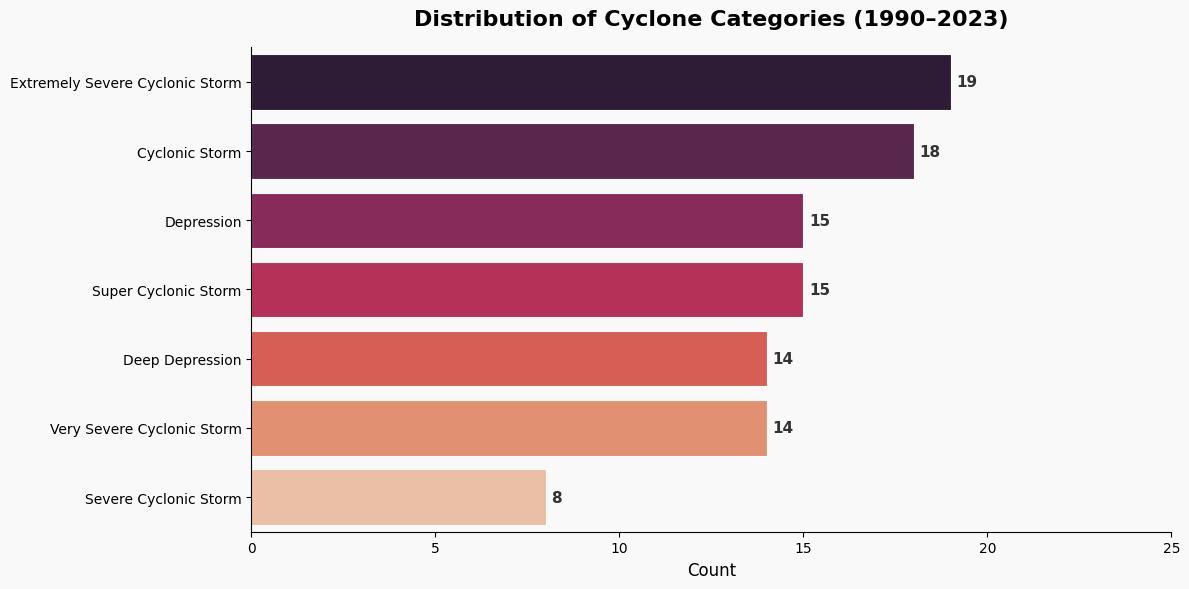

In [6]:
cat_order = df['category'].value_counts().index.tolist()
palette = sns.color_palette('rocket', len(cat_order))

fig, ax = plt.subplots(figsize=(12, 6))
bars = sns.countplot(data=df, y='category', order=cat_order, palette=palette, ax=ax, edgecolor='white', linewidth=0.8)

for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', (p.get_width() + 0.15, p.get_y() + p.get_height() / 2),
                va='center', ha='left', fontsize=11, fontweight='bold', color='#333')

ax.set_title('Distribution of Cyclone Categories (1990–2023)', fontsize=16, fontweight='bold', pad=16)
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('')
ax.set_xlim(0, 25)
fig.patch.set_facecolor('#f9f9f9')
ax.set_facecolor('#f9f9f9')
plt.tight_layout()
plt.savefig('01_category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Yearly Cyclone Frequency (Line + Area Chart)

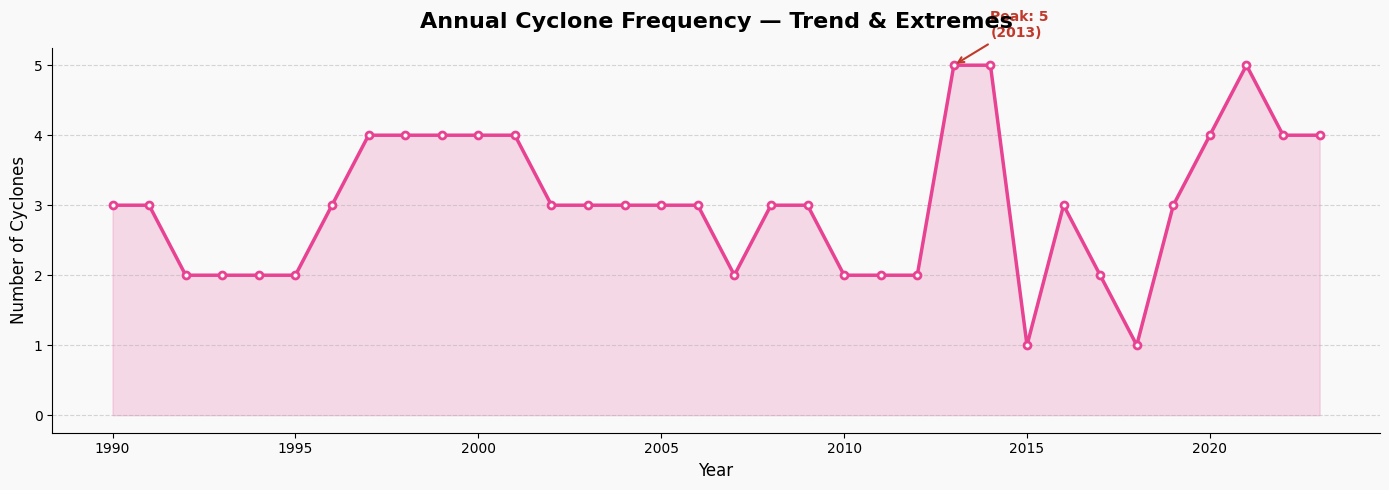

In [7]:
yearly = df.groupby('year').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(yearly['year'], yearly['count'], alpha=0.18, color='#e84393')
ax.plot(yearly['year'], yearly['count'], color='#e84393', lw=2.5, marker='o', markersize=5, markerfacecolor='white', markeredgewidth=2)

# Annotate extremes
peak_yr = yearly.loc[yearly['count'].idxmax()]
ax.annotate(f"Peak: {int(peak_yr['count'])}\n({int(peak_yr['year'])})",
            xy=(peak_yr['year'], peak_yr['count']), xytext=(peak_yr['year']+1, peak_yr['count']+0.4),
            fontsize=10, color='#c0392b', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5))

ax.set_title('Annual Cyclone Frequency — Trend & Extremes', fontsize=16, fontweight='bold', pad=14)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Cyclones', fontsize=12)
ax.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('#f9f9f9')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('02_yearly_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Monthly Cyclone Seasonality (Polar Bar Chart)

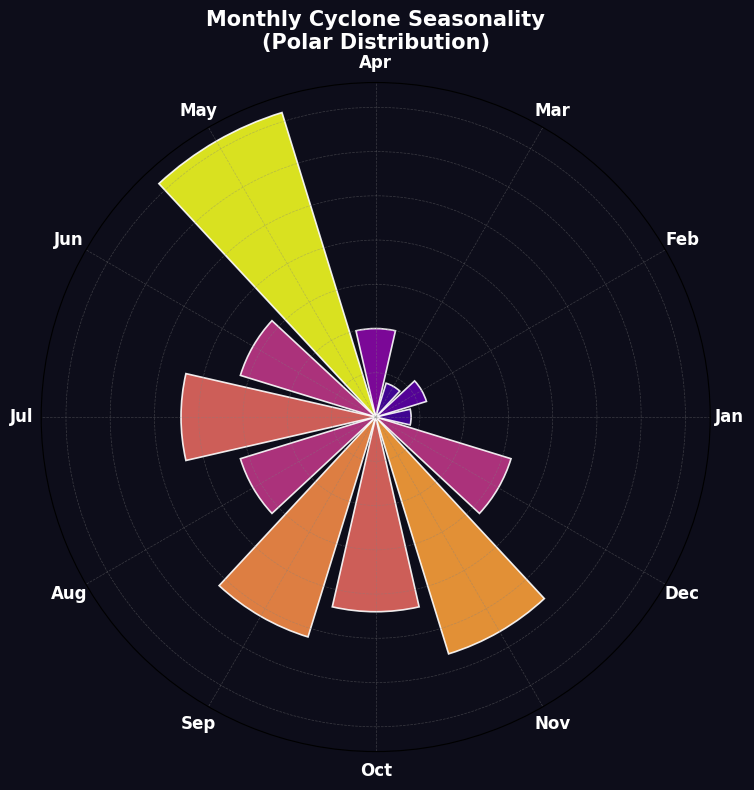

In [8]:
month_count = df.groupby('month').size().reindex(range(1, 13), fill_value=0)
months_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
angles = np.linspace(0, 2 * np.pi, 12, endpoint=False)
values = month_count.values
colors = plt.cm.plasma(values / values.max())

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
bars = ax.bar(angles, values, width=0.45, color=colors, edgecolor='white', linewidth=1.2, alpha=0.9)
ax.set_xticks(angles)
ax.set_xticklabels(months_labels, fontsize=12, fontweight='bold')
ax.set_yticklabels([])
ax.set_title('Monthly Cyclone Seasonality\n(Polar Distribution)', fontsize=15, fontweight='bold', pad=24)
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.4)
fig.patch.set_facecolor('#0d0d1a')
ax.set_facecolor('#0d0d1a')
ax.title.set_color('white')
for label in ax.get_xticklabels():
    label.set_color('white')
plt.tight_layout()
plt.savefig( '03_monthly_polar.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

---
## 4. Max Wind Speed Distribution by Category (Violin + Strip Plot)

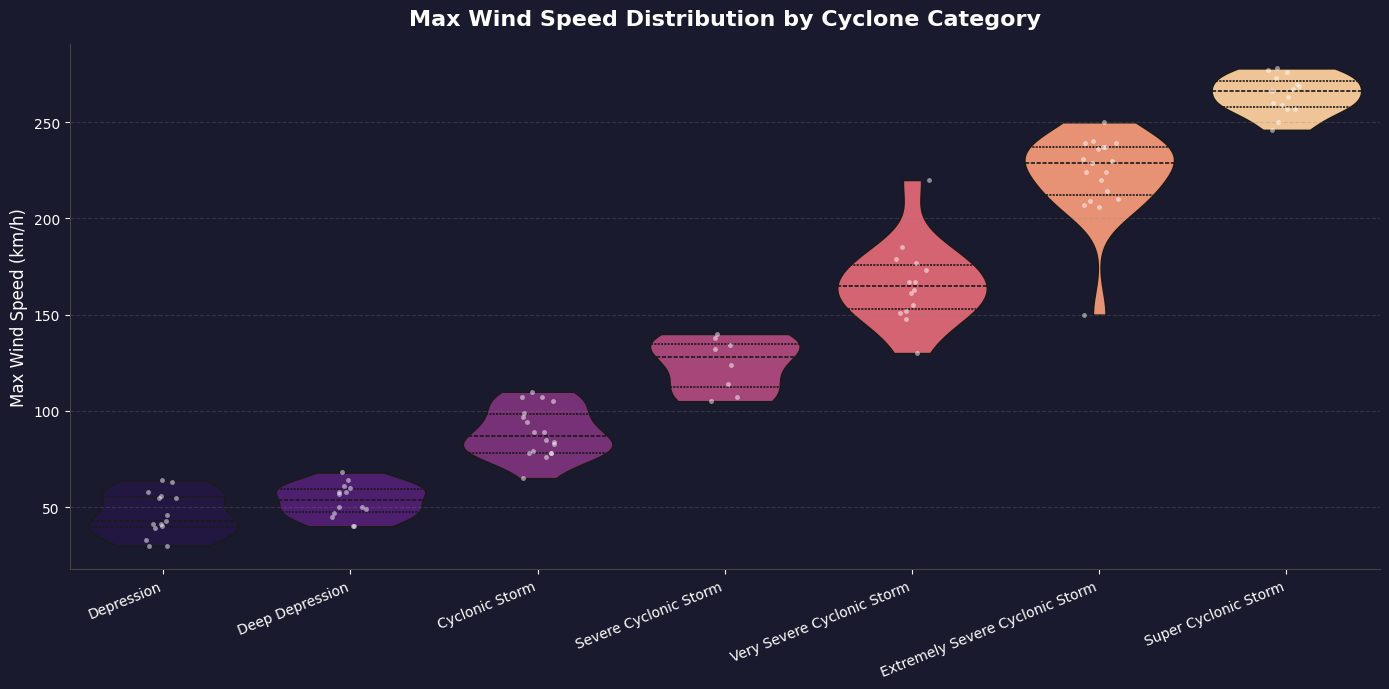

In [9]:
cat_order2 = ['Depression','Deep Depression','Cyclonic Storm','Severe Cyclonic Storm',
              'Very Severe Cyclonic Storm','Extremely Severe Cyclonic Storm','Super Cyclonic Storm']
cat_order2 = [c for c in cat_order2 if c in df['category'].unique()]
palette2 = sns.color_palette('magma', len(cat_order2))

fig, ax = plt.subplots(figsize=(14, 7))
sns.violinplot(data=df, x='category', y='max_wind_kmh', order=cat_order2, palette=palette2,
               inner='quartile', ax=ax, linewidth=1.2, cut=0)
sns.stripplot(data=df, x='category', y='max_wind_kmh', order=cat_order2,
              color='white', alpha=0.5, size=3.5, jitter=True, ax=ax)

ax.set_xticklabels(ax.get_xticklabels(), rotation=22, ha='right', fontsize=10)
ax.set_title('Max Wind Speed Distribution by Cyclone Category', fontsize=16, fontweight='bold', pad=14)
ax.set_xlabel('')
ax.set_ylabel('Max Wind Speed (km/h)', fontsize=12)
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax.title.set_color('white')
ax.yaxis.label.set_color('white')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#444')
ax.grid(axis='y', linestyle='--', alpha=0.25, color='grey')
plt.tight_layout()
plt.savefig( '04_wind_violin.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

---
## 5. Deaths vs Damage Scatter (Log Scale with Category Hue)

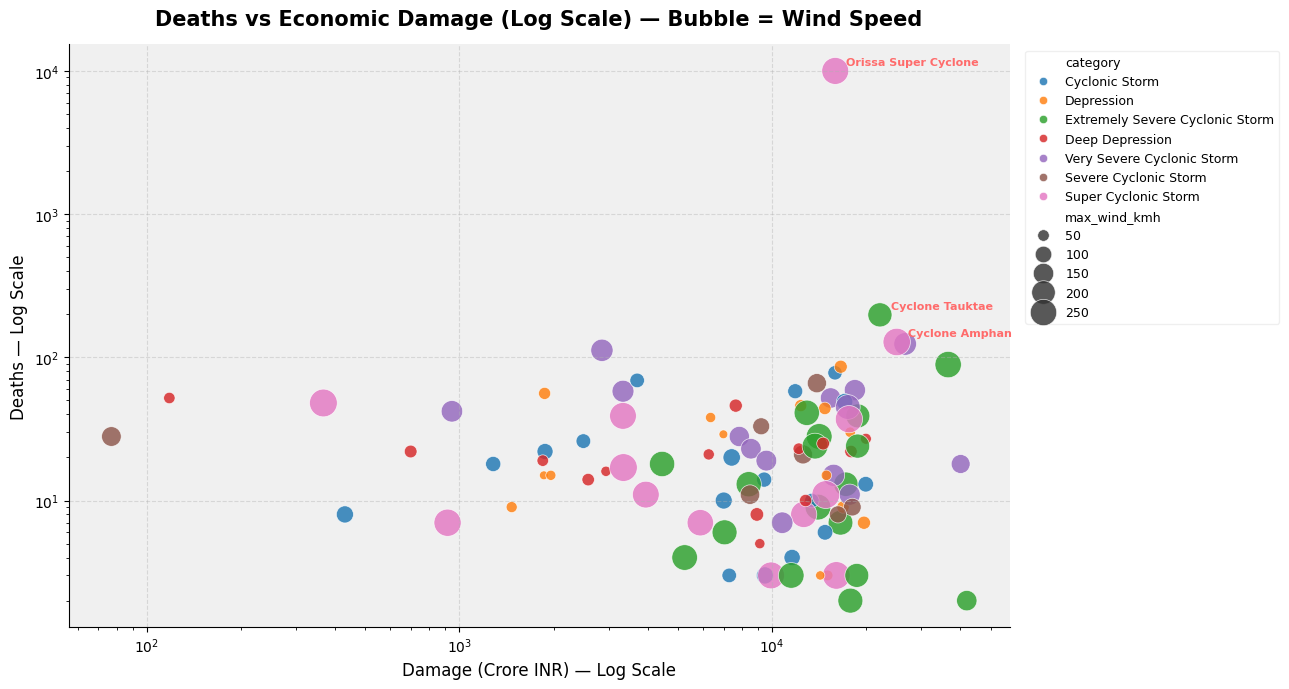

In [10]:
df_plot = df[(df['deaths'] > 0) & (df['damage_crore_inr'] > 0)].copy()
palette3 = sns.color_palette('tab10', n_colors=df['category'].nunique())

fig, ax = plt.subplots(figsize=(13, 7))
scatter = sns.scatterplot(data=df_plot, x='damage_crore_inr', y='deaths',
                          hue='category', size='max_wind_kmh', sizes=(40, 400),
                          palette='tab10', alpha=0.82, ax=ax, edgecolor='white', linewidth=0.5)

ax.set_xscale('log')
ax.set_yscale('log')

# Annotate top deadly events
top5 = df_plot.nlargest(3, 'deaths')
for _, row in top5.iterrows():
    ax.annotate(row['event_name'], (row['damage_crore_inr'], row['deaths']),
                xytext=(8, 4), textcoords='offset points', fontsize=8, color='#ff6b6b', fontweight='bold')

ax.set_title('Deaths vs Economic Damage (Log Scale) — Bubble = Wind Speed', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Damage (Crore INR) — Log Scale', fontsize=12)
ax.set_ylabel('Deaths — Log Scale', fontsize=12)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, framealpha=0.3)
ax.set_facecolor('#f0f0f0')
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig( '05_deaths_damage_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Heatmap — Month vs Year (Cyclone Count)

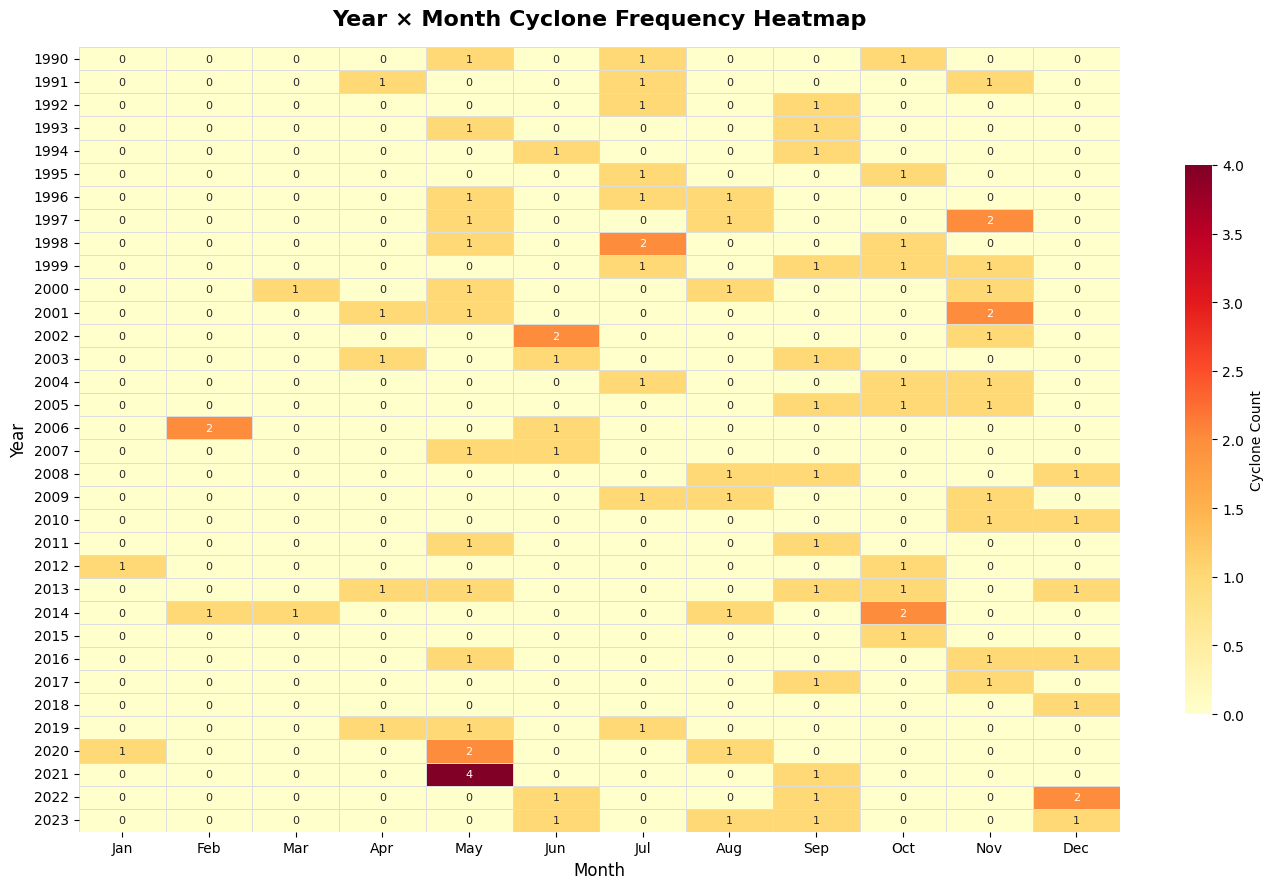

In [11]:
pivot = df.groupby(['year', 'month']).size().unstack(fill_value=0)
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][:len(pivot.columns)]

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.4, linecolor='#ddd', ax=ax,
            annot=True, fmt='d', cbar_kws={'label': 'Cyclone Count', 'shrink': 0.7},
            annot_kws={'fontsize': 8})
ax.set_title('Year × Month Cyclone Frequency Heatmap', fontsize=16, fontweight='bold', pad=16)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Year', fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('06_heatmap_year_month.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Basin Comparison — Stacked Bar (Category Split)

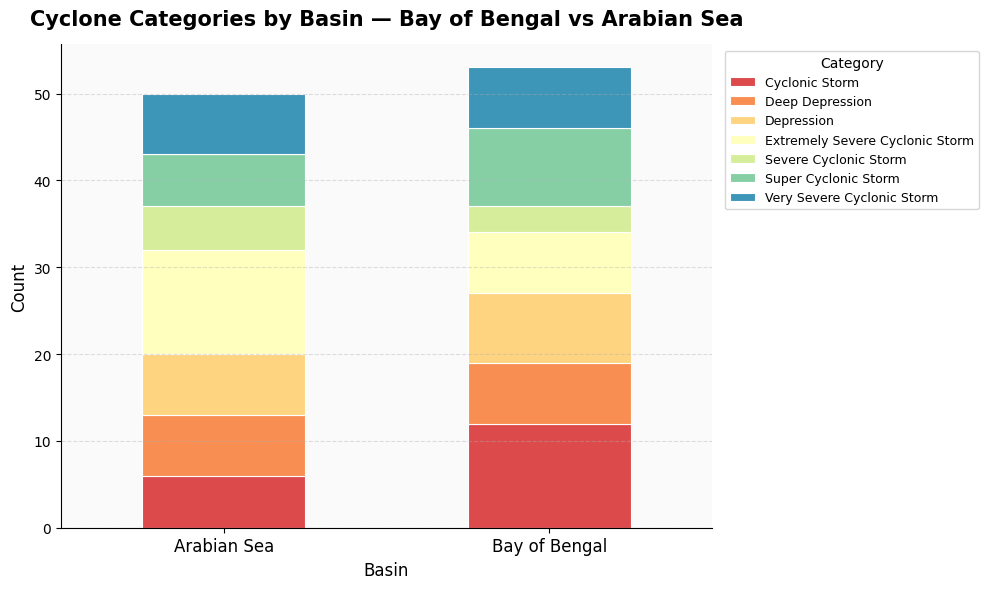

In [12]:
basin_cat = df.groupby(['basin', 'category']).size().unstack(fill_value=0)
colors_stacked = sns.color_palette('Spectral', len(basin_cat.columns))

fig, ax = plt.subplots(figsize=(10, 6))
basin_cat.plot(kind='bar', stacked=True, color=colors_stacked, ax=ax,
               edgecolor='white', linewidth=0.8)
ax.set_title('Cyclone Categories by Basin — Bay of Bengal vs Arabian Sea', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Basin', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=12)
ax.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.set_facecolor('#fafafa')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig( '07_basin_category_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Top 10 Deadliest Cyclones (Horizontal Bar)

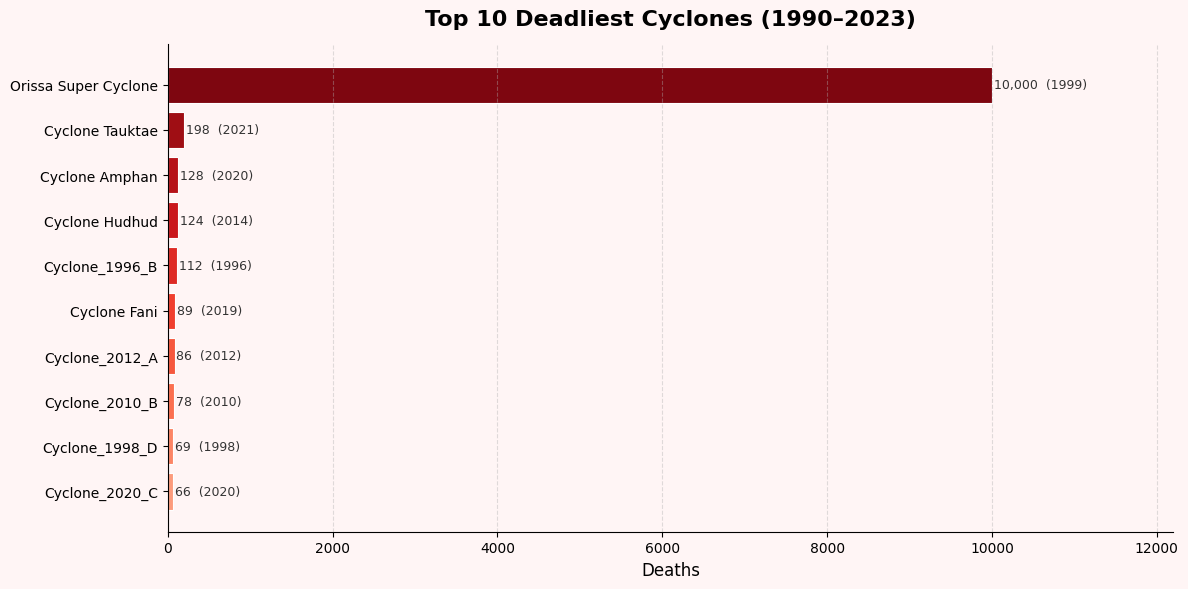

In [13]:
top10 = df.nlargest(10, 'deaths')[['event_name', 'deaths', 'year', 'category']].sort_values('deaths')
colors_death = plt.cm.Reds(np.linspace(0.35, 0.95, 10))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10['event_name'], top10['deaths'], color=colors_death, edgecolor='white', linewidth=0.8)

for bar, (_, row) in zip(bars, top10.iterrows()):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f"{row['deaths']:,}  ({row['year']})", va='center', fontsize=9, color='#333')

ax.set_title('Top 10 Deadliest Cyclones (1990–2023)', fontsize=16, fontweight='bold', pad=14)
ax.set_xlabel('Deaths', fontsize=12)
ax.set_xlim(0, top10['deaths'].max() * 1.22)
ax.set_facecolor('#fff5f5')
fig.patch.set_facecolor('#fff5f5')
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('08_top10_deadliest.png', dpi=150, bbox_inches='tight', facecolor='#fff5f5')
plt.show()

---
## 9. Correlation Heatmap (Numerical Features)

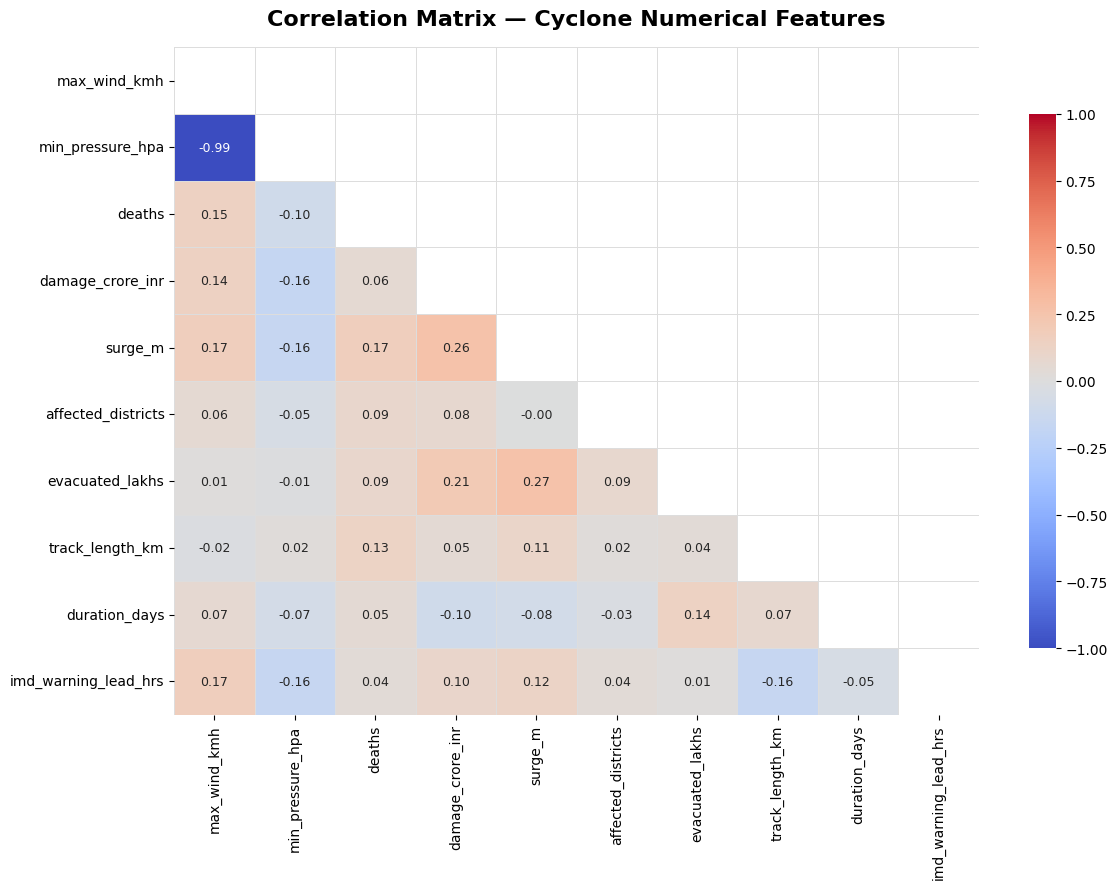

In [14]:
num_cols = ['max_wind_kmh','min_pressure_hpa','deaths','damage_crore_inr',
            'surge_m','affected_districts','evacuated_lakhs','track_length_km',
            'duration_days','imd_warning_lead_hrs']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5, linecolor='#ddd', ax=ax,
            cbar_kws={'shrink': 0.8}, annot_kws={'fontsize': 9})
ax.set_title('Correlation Matrix — Cyclone Numerical Features', fontsize=16, fontweight='bold', pad=16)
plt.tight_layout()
plt.savefig('09_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Wind Speed vs Pressure (Scatter + Regression)

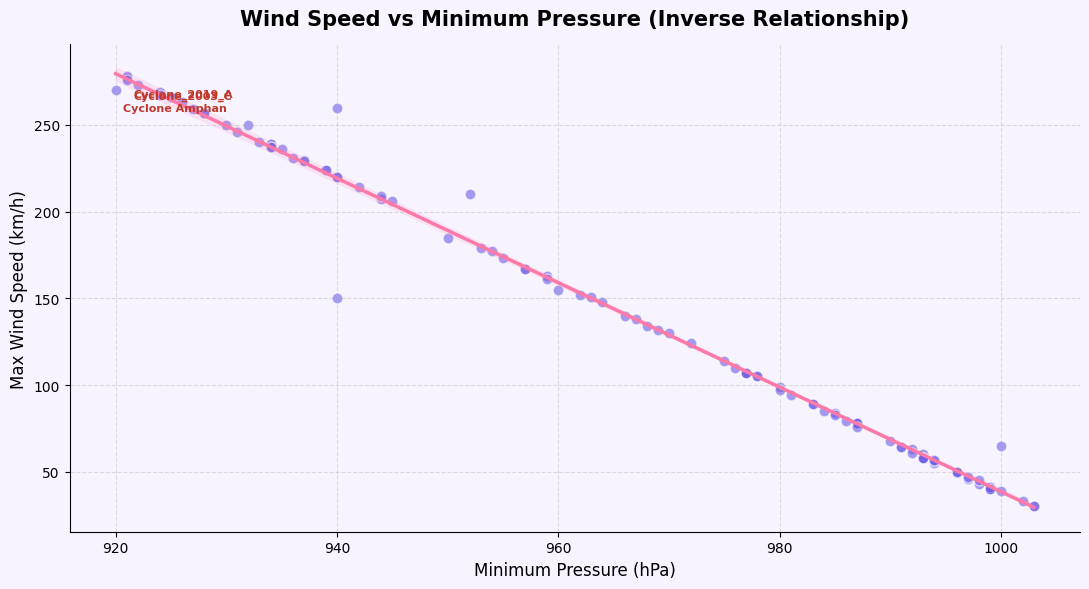

In [15]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.regplot(data=df, x='min_pressure_hpa', y='max_wind_kmh', ax=ax,
            scatter_kws={'alpha': 0.6, 'color': '#6c5ce7', 's': 60, 'edgecolor': 'white'},
            line_kws={'color': '#fd79a8', 'lw': 2.5})

ax.set_title('Wind Speed vs Minimum Pressure (Inverse Relationship)', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Minimum Pressure (hPa)', fontsize=12)
ax.set_ylabel('Max Wind Speed (km/h)', fontsize=12)
ax.set_facecolor('#f8f4ff')
fig.patch.set_facecolor('#f8f4ff')
ax.grid(linestyle='--', alpha=0.4)
# Mark extremes
extreme = df.nsmallest(3, 'min_pressure_hpa')
for _, r in extreme.iterrows():
    ax.annotate(r['event_name'], (r['min_pressure_hpa'], r['max_wind_kmh']),
                xytext=(5, -15), textcoords='offset points', fontsize=8, color='#c0392b', fontweight='bold')
plt.tight_layout()
plt.savefig('10_wind_pressure_scatter.png', dpi=150, bbox_inches='tight', facecolor='#f8f4ff')
plt.show()

---
## 11. Landfall State — Donut Chart

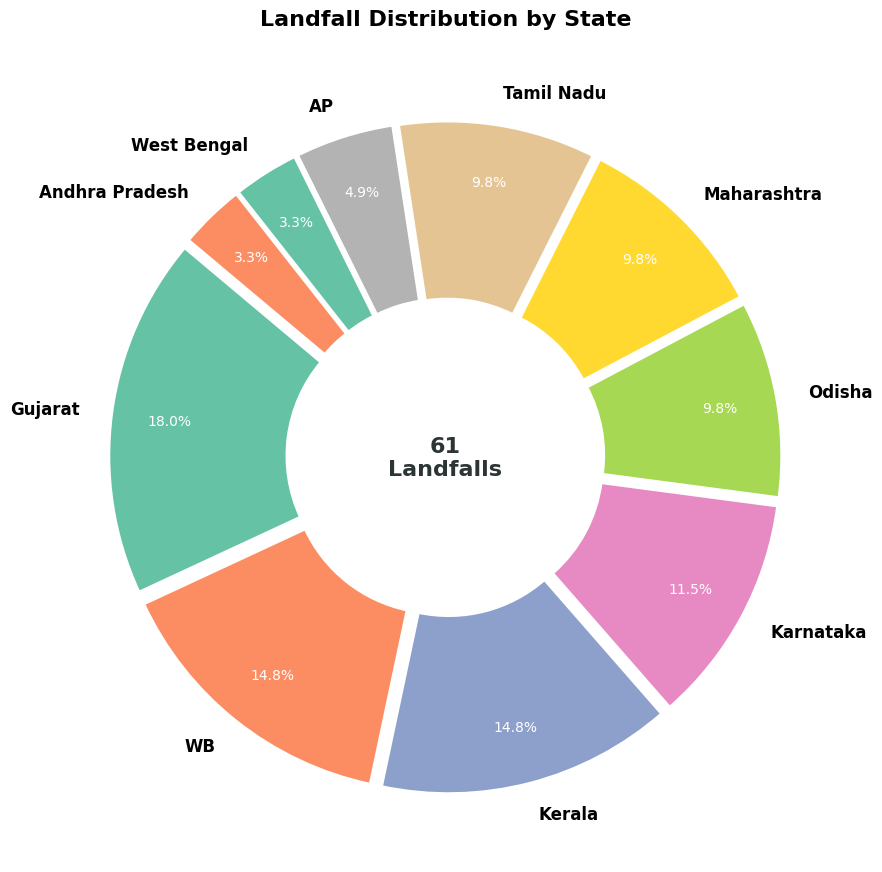

In [16]:
state_counts = df[df['landfall'] == True]['landfall_state'].value_counts()
colors_donut = sns.color_palette('Set2', len(state_counts))
explode = [0.04] * len(state_counts)

fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    state_counts.values, labels=state_counts.index,
    autopct='%1.1f%%', colors=colors_donut, explode=explode,
    startangle=140, pctdistance=0.82,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
for t in texts: t.set_fontsize(12); t.set_fontweight('bold')
for a in autotexts: a.set_fontsize(10); a.set_color('white')

ax.text(0, 0, f'{state_counts.sum()}\nLandfalls', ha='center', va='center', fontsize=16, fontweight='bold', color='#2d3436')
ax.set_title('Landfall Distribution by State', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('11_landfall_donut.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Storm Surge Distribution — KDE + Histogram

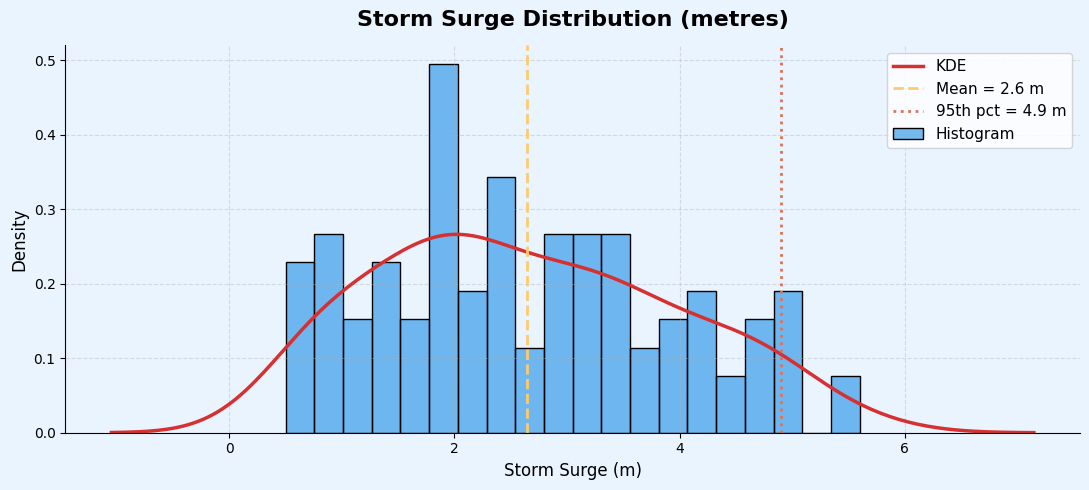

In [17]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.histplot(df['surge_m'], bins=20, color='#0984e3', alpha=0.55, ax=ax, stat='density', label='Histogram')
sns.kdeplot(df['surge_m'], color='#d63031', lw=2.5, ax=ax, label='KDE')

ax.axvline(df['surge_m'].mean(), color='#fdcb6e', lw=2, linestyle='--', label=f"Mean = {df['surge_m'].mean():.1f} m")
ax.axvline(df['surge_m'].quantile(0.95), color='#e17055', lw=2, linestyle=':', label=f"95th pct = {df['surge_m'].quantile(0.95):.1f} m")

ax.set_title('Storm Surge Distribution (metres)', fontsize=16, fontweight='bold', pad=14)
ax.set_xlabel('Storm Surge (m)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=11)
ax.set_facecolor('#eaf4ff')
fig.patch.set_facecolor('#eaf4ff')
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig( '12_surge_kde.png', dpi=150, bbox_inches='tight', facecolor='#eaf4ff')
plt.show()

---
## 13. Duration vs Track Length — Hexbin Density

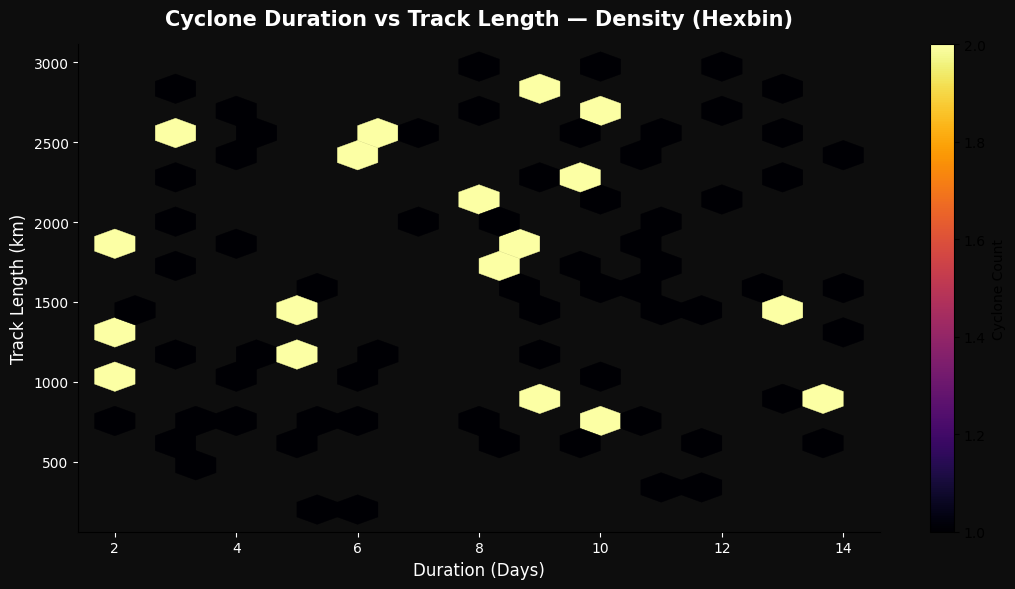

In [18]:
fig, ax = plt.subplots(figsize=(11, 6))
hb = ax.hexbin(df['duration_days'], df['track_length_km'], gridsize=18,
               cmap='inferno', mincnt=1, linewidths=0.3)
cb = fig.colorbar(hb, ax=ax, label='Cyclone Count')
cb.ax.tick_params(labelsize=10)

ax.set_title('Cyclone Duration vs Track Length — Density (Hexbin)', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Duration (Days)', fontsize=12)
ax.set_ylabel('Track Length (km)', fontsize=12)
ax.set_facecolor('#0d0d0d')
fig.patch.set_facecolor('#0d0d0d')
ax.title.set_color('white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.tick_params(colors='white')
plt.tight_layout()
plt.savefig( '13_duration_track_hexbin.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

---
## 14. Decade-wise Damage Trend — Box Plot

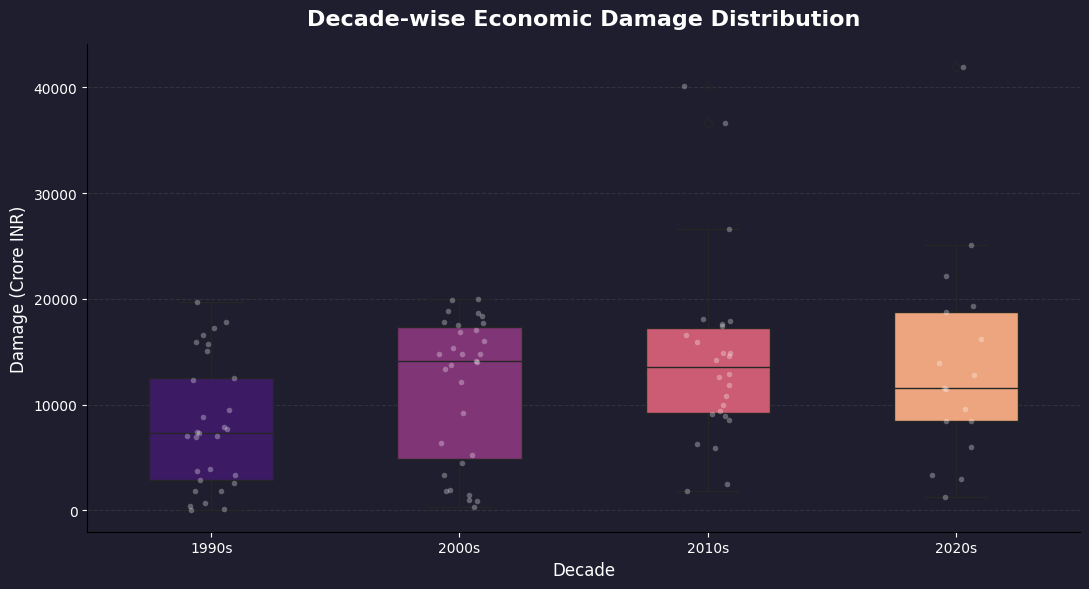

In [19]:
df['decade'] = (df['year'] // 10) * 10
decade_labels = {1990: '1990s', 2000: '2000s', 2010: '2010s', 2020: '2020s'}
df['decade_label'] = df['decade'].map(decade_labels)

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=df, x='decade_label', y='damage_crore_inr', palette='magma',
            order=['1990s','2000s','2010s','2020s'], ax=ax, width=0.5,
            flierprops=dict(marker='D', color='#e74c3c', markersize=5, alpha=0.7))
sns.stripplot(data=df, x='decade_label', y='damage_crore_inr',
              order=['1990s','2000s','2010s','2020s'], color='white',
              alpha=0.3, size=4, jitter=True, ax=ax)

ax.set_title('Decade-wise Economic Damage Distribution', fontsize=16, fontweight='bold', pad=14)
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('Damage (Crore INR)', fontsize=12)
ax.set_facecolor('#1e1e2e')
fig.patch.set_facecolor('#1e1e2e')
ax.title.set_color('white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.tick_params(colors='white')
ax.grid(axis='y', linestyle='--', alpha=0.2, color='grey')
plt.tight_layout()
plt.savefig('14_decade_damage_box.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()

---
## 15. Pairplot — Key Extreme-Pattern Variables

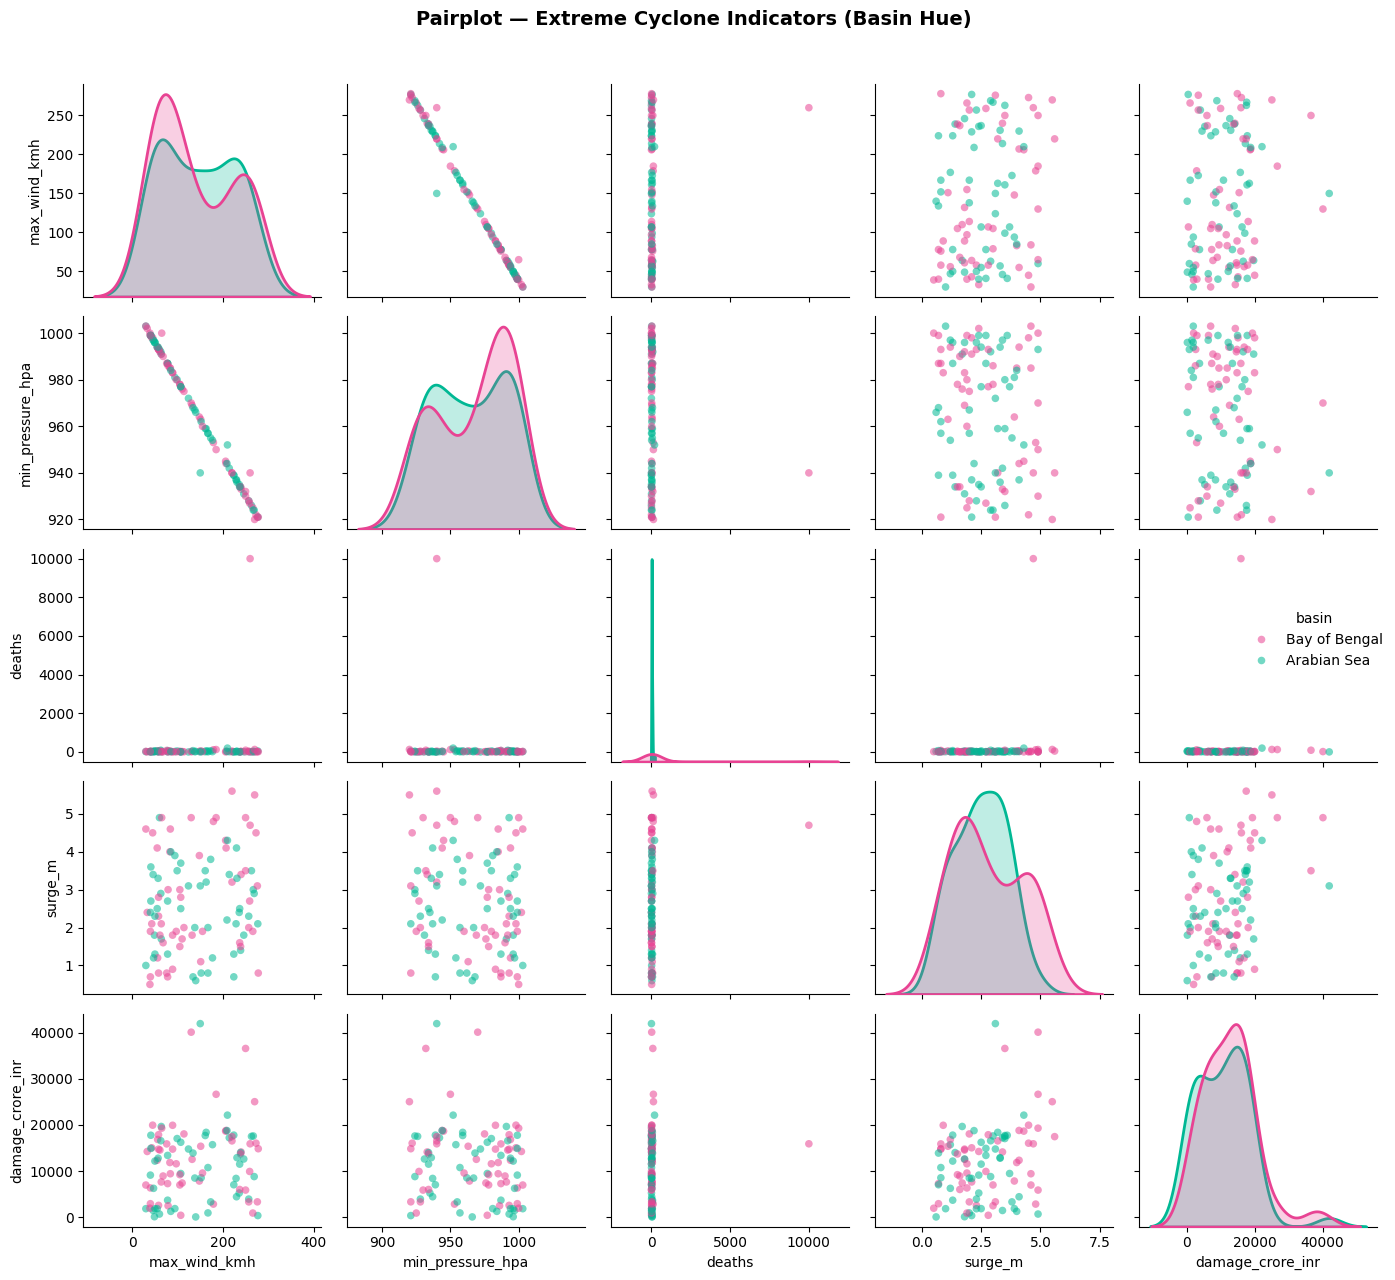

In [20]:
pair_cols = ['max_wind_kmh', 'min_pressure_hpa', 'deaths', 'surge_m', 'damage_crore_inr']
g = sns.pairplot(df[pair_cols + ['basin']], hue='basin', palette={'Bay of Bengal':'#e84393','Arabian Sea':'#00b894'},
                 diag_kind='kde', plot_kws={'alpha':0.55, 'edgecolor':'none', 's':30},
                 diag_kws={'lw':2})
g.figure.suptitle('Pairplot — Extreme Cyclone Indicators (Basin Hue)', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig( '15_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

---
## ✅ All charts saved to `charts/` folder

In [21]:
import os
files = sorted(os.listdir(CHARTS))
print(f'Total charts saved: {len(files)}')
for f in files:
    print(' -', f)

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'charts/'